# Dietly — DietDiary Machine Learning

## 1. Business Understanding

### Business Problem

Dietly is a nutrition tracking web application that allows users
to record their meals and monitor their weight history.

The application provides a prediction feature to estimate future
weight based on historical dietary and weight information.

### Business Question

> Based on a user's historical weight and dietary records,
> what is the estimated future weight?

### Machine Learning Objective

Build a supervised regression model that predicts future weight
using features that can be derived from Dietly's existing
meal and weight tracking data.

The final model will be exported as a `.joblib` file and exposed
through `predict.py` so that it can be integrated into the
Django backend.

## Dataset

The DietDiary dataset contains daily dietary diary information
and corresponding weight measurements.

The dataset source is:

https://github.com/yxG1005/Weight_Prediction

The dataset will be assessed, cleaned, explored, and transformed
before being used for machine learning.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
from pathlib import Path

raw_dir = Path("../data/raw")

print("Dataset directory:")
print(raw_dir.resolve())

print("\nFiles:")
for file in raw_dir.iterdir():
    print(file.name)

In [3]:
data_path = raw_dir / "data.csv"

df = pd.read_csv(data_path)

print("Shape:", df.shape)

Shape: (5251, 7)


In [4]:
display(df.head())

,ID,date,breakfast,lunch,supper,start_weight,weight
0,721c929849fc713ce020c5a3e748f73f,2020/11/17,breakfast/293290_20201117_breakfast_1605569539...,lunch/293290_20201117_lunch_1605617876_1.jpg||...,supper/293290_20201117_supper_1605617925_1.jpg...,78.8,78.4
1,721c929849fc713ce020c5a3e748f73f,2020/11/18,breakfast/293290_20201118_breakfast_1605667215...,lunch/293290_20201118_lunch_1605699259_1.jpg||...,supper/293290_20201118_supper_1605699286_1.jpg...,78.4,79.3
2,721c929849fc713ce020c5a3e748f73f,2020/11/19,breakfast/293290_20201119_breakfast_1605751810...,lunch/293290_20201119_lunch_1605792865_1.jpg||...,supper/293290_20201119_supper_1605792895_1.jpg|||,79.3,79.5
3,721c929849fc713ce020c5a3e748f73f,2020/11/20,breakfast/293290_20201120_breakfast_1605827326...,lunch/293290_20201120_lunch_1605860284_1.jpg|||,supper/293290_20201120_supper_1605878086_1.jpg...,79.5,78.5
4,721c929849fc713ce020c5a3e748f73f,2020/11/21,breakfast/293290_20201121_breakfast_1605917741...,lunch/293290_20201121_lunch_1605951359_1.jpg||...,supper/293290_20201121_supper_1605961855_1.jpg...,78.5,77.9


In [5]:
print(df.columns.tolist())

['ID', 'date', 'breakfast', 'lunch', 'supper', 'start_weight', 'weight']


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5251 entries, 0 to 5250
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            5251 non-null   str    
 1   date          5251 non-null   str    
 2   breakfast     5251 non-null   str    
 3   lunch         5251 non-null   str    
 4   supper        5251 non-null   str    
 5   start_weight  5251 non-null   float64
 6   weight        5251 non-null   float64
dtypes: float64(2), str(5)
memory usage: 1.8 MB


In [7]:
display(
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

ID              0
date            0
breakfast       0
lunch           0
supper          0
start_weight    0
weight          0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 2. Data Assessment

The initial assessment shows that the dataset contains 5,251
records and 7 columns.

There are no missing values and no duplicate rows.

Further assessment is performed to understand the number of
participants, observation period, weight distribution, and
the structure of dietary records before data cleaning and
feature engineering.

In [9]:
print("Number of unique users:", df["ID"].nunique())

Number of unique users: 611


In [10]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Start date: 2017/10/1
End date: 2021/4/9


In [11]:
records_per_user = df.groupby("ID").size()

print("Minimum records per user:", records_per_user.min())
print("Maximum records per user:", records_per_user.max())
print("Average records per user:", records_per_user.mean())

Minimum records per user: 5
Maximum records per user: 84
Average records per user: 8.594108019639934


In [12]:
display(records_per_user.describe())

count    611.000000
mean       8.594108
std        7.558877
min        5.000000
25%        6.000000
50%        6.000000
75%        6.000000
max       84.000000
dtype: float64

In [13]:
display(
    df[["start_weight", "weight"]].describe()
)

,start_weight,weight
count,5251.000000,5251.000000
mean,68.231442,68.082061
std,13.092886,13.066507
min,41.800000,41.600000
25%,58.000000,58.000000
50%,65.900000,65.800000
75%,76.400000,76.200000
max,124.000000,122.300000


### Temporal Structure

The dataset contains multiple daily records for each participant.
Therefore, the records are examined chronologically to understand
the relationship between historical observations and subsequent
weight measurements.

In [14]:
df["date"] = pd.to_datetime(df["date"])

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

Date range:
2017-09-08 00:00:00 to 2021-04-14 00:00:00


In [15]:
print("Date duplicates:", df["date"].duplicated().sum())

Date duplicates: 4594


In [16]:
user_date_duplicates = df.duplicated(subset=["ID", "date"]).sum()

print("Duplicate user-date records:", user_date_duplicates)

Duplicate user-date records: 0


In [17]:
df_sorted = df.sort_values(["ID", "date"]).copy()

df_sorted["days_since_previous"] = (
    df_sorted.groupby("ID")["date"]
    .diff()
    .dt.days
)

display(
    df_sorted["days_since_previous"]
    .describe()
)

count    4640.000000
mean        1.373060
std         6.740393
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       261.000000
Name: days_since_previous, dtype: float64

In [18]:
display(
    df_sorted[
        ["ID", "date", "start_weight", "weight", "days_since_previous"]
    ].head(20)
)

,ID,date,start_weight,weight,days_since_previous
714,0060b6899180e194092d60a0e50aeea1,2019-02-22,69.0,68.3,NaN
715,0060b6899180e194092d60a0e50aeea1,2019-02-23,68.3,68.8,1.0
716,0060b6899180e194092d60a0e50aeea1,2019-02-24,68.8,68.2,1.0
717,0060b6899180e194092d60a0e50aeea1,2019-02-25,68.2,68.2,1.0
718,0060b6899180e194092d60a0e50aeea1,2019-02-26,68.2,68.2,1.0
719,0060b6899180e194092d60a0e50aeea1,2019-02-27,68.2,68.2,1.0
1076,0176f16327965da04ee40c41cc4df2e5,2019-01-10,75.7,74.8,NaN
1077,0176f16327965da04ee40c41cc4df2e5,2019-01-11,74.8,75.0,1.0
1078,0176f16327965da04ee40c41cc4df2e5,2019-01-12,75.0,74.3,1.0
1079,0176f16327965da04ee40c41cc4df2e5,2019-01-13,74.3,73.8,1.0


### Consecutive Daily Records

Most participants have daily observations, but some records may
contain gaps between observations.

For future-weight prediction, consecutive observations are more
appropriate because they allow the model to learn the relationship
between recent history and the next observed day.

In [19]:
gap_counts = (
    df_sorted["days_since_previous"]
    .value_counts()
    .sort_index()
)

display(gap_counts.head(15))

days_since_previous
1.0     4578
2.0       16
3.0        4
4.0        8
5.0        6
8.0        3
9.0        2
12.0       1
15.0       1
18.0       2
19.0       1
21.0       2
22.0       1
23.0       1
27.0       1
Name: count, dtype: int64

In [20]:
print(
    "Records with consecutive previous day:",
    (df_sorted["days_since_previous"] == 1).sum()
)

print(
    "Records with gaps greater than 1 day:",
    (df_sorted["days_since_previous"] > 1).sum()
)

Records with consecutive previous day: 4578
Records with gaps greater than 1 day: 62


In [21]:
display(
    df_sorted[
        df_sorted["days_since_previous"] > 1
    ][
        ["ID", "date", "start_weight", "weight", "days_since_previous"]
    ]
    .sort_values("days_since_previous", ascending=False)
    .head(20)
)

,ID,date,start_weight,weight,days_since_previous
3843,35699059407f16c595db8e25ad5aa4d7,2019-04-12,62.7,65.1,261.0
2675,51cd4136fae8f532f542d3425e509206,2019-04-12,55.9,54.5,211.0
4593,bcfc06227ae641791bd26076cc52cb06,2018-08-28,61.6,60.1,134.0
1446,9054eb8e88fa1b385beb549cfe5da0e1,2019-04-12,49.0,48.7,127.0
2357,3f81dc345767e9e933cd5fd5d85bbb0a,2019-01-22,60.7,62.5,124.0
1003,85ce1f49be73c83d29dd3a6f87c50ba7,2019-05-08,57.0,58.1,112.0
1789,fa947354f7b241f4ee5602a7b1511faa,2019-01-17,88.0,87.8,89.0
959,60014da4cf2c92960e52421d81303e35,2019-04-12,74.0,74.9,87.0
2189,d602babdeaa3c94781811a8b92e17ffa,2018-12-19,54.5,54.5,84.0
4997,fb31bf0604ccc2dd899fccc2cebd7152,2017-12-15,76.9,75.5,65.0


In [22]:
display(
    df_sorted[
        ["date", "breakfast", "lunch", "supper"]
    ].head(10)
)

,date,breakfast,lunch,supper
714,2019-02-22,breakfast/239178_20190222_breakfast_1550791872...,lunch/239178_20190222_lunch_1550809328.jpg|||f...,supper/239178_20190222_supper_1550831970.jpg||...
715,2019-02-23,breakfast/239178_20190223_breakfast_1550878183...,lunch/239178_20190223_lunch_1550895596.jpg|||c...,supper/239178_20190223_supper_1550917591.jpg||...
716,2019-02-24,breakfast/239178_20190224_breakfast_1550977313...,lunch/239178_20190224_lunch_1550983320.jpg|||c...,supper/239178_20190224_supper_1551004976.jpg||...
717,2019-02-25,breakfast/239178_20190225_breakfast_1551059759...,lunch/239178_20190225_lunch_1551071119.jpg|||n...,supper/239178_20190225_supper_1551096272.jpg||...
718,2019-02-26,breakfast/239178_20190226_breakfast_1551134857...,lunch/239178_20190226_lunch_1551155800.jpg|||v...,supper/239178_20190226_supper_1551182687.jpg;s...
719,2019-02-27,breakfast/239178_20190227_breakfast_1551221809...,lunch/239178_20190227_lunch_1551239608.jpg;lun...,supper/239178_20190227_supper_1551272319.jpg||...
1076,2019-01-10,breakfast/236404_20190110_breakfast_1547082949...,lunch/236404_20190110_lunch_1547093030.jpg|||f...,supper/236404_20190110_supper_1547113104.jpg||...
1077,2019-01-11,breakfast/236404_20190111_breakfast_1547167516...,lunch/236404_20190111_lunch_1547178469.jpg|||rice,supper/236404_20190111_supper_1547199269.jpg||...
1078,2019-01-12,breakfast/236404_20190112_breakfast_1547262170...,lunch/236404_20190112_lunch_1547264228.jpg|||e...,supper/236404_20190112_supper_1547288080.jpg||...
1079,2019-01-13,breakfast/236404_20190113_breakfast_1547337824...,lunch/236404_20190113_lunch_1547355976.jpg|||s...,supper/236404_20190113_supper_1547378259.jpg||...


### Dietary Record Assessment

The dietary fields contain meal image paths and, in some cases,
ingredient annotations separated by `|||`.

The meal records are further assessed to determine how much
ingredient information is available and how the dietary text
can be transformed into features for machine learning.

In [23]:
meal_columns = ["breakfast", "lunch", "supper"]

for col in meal_columns:
    print(f"\n=== {col.upper()} ===")
    
    contains_annotation = df[col].str.contains(
        r"\|\|\|",
        regex=True,
        na=False
    )
    
    print("Records with ingredient annotation:", contains_annotation.sum())
    print("Records without ingredient annotation:", (~contains_annotation).sum())


=== BREAKFAST ===
Records with ingredient annotation: 5251
Records without ingredient annotation: 0

=== LUNCH ===
Records with ingredient annotation: 5251
Records without ingredient annotation: 0

=== SUPPER ===
Records with ingredient annotation: 5251
Records without ingredient annotation: 0


In [24]:
for col in meal_columns:
    print(f"\n=== {col.upper()} EXAMPLES ===")
    display(df[col].head(10))


=== BREAKFAST EXAMPLES ===


0    breakfast/293290_20201117_breakfast_1605569539...
1    breakfast/293290_20201118_breakfast_1605667215...
2    breakfast/293290_20201119_breakfast_1605751810...
3    breakfast/293290_20201120_breakfast_1605827326...
4    breakfast/293290_20201121_breakfast_1605917741...
5    breakfast/293290_20201122_breakfast_1606009531...
6    breakfast/293290_20201123_breakfast_1606086006...
7    breakfast/293290_20201124_breakfast_1606172978...
8    breakfast/293290_20201125_breakfast_1606260245...
9    breakfast/293290_20201126_breakfast_1606345339...
Name: breakfast, dtype: str


=== LUNCH EXAMPLES ===


0    lunch/293290_20201117_lunch_1605617876_1.jpg||...
1    lunch/293290_20201118_lunch_1605699259_1.jpg||...
2    lunch/293290_20201119_lunch_1605792865_1.jpg||...
3      lunch/293290_20201120_lunch_1605860284_1.jpg|||
4    lunch/293290_20201121_lunch_1605951359_1.jpg||...
5                                                  |||
6    lunch/293290_20201123_lunch_1606114559_1.jpg||...
7      lunch/293290_20201124_lunch_1606213847_1.jpg|||
8    lunch/293290_20201125_lunch_1606278501_1.jpg||...
9    lunch/293290_20201126_lunch_1606364506_1.jpg||...
Name: lunch, dtype: str


=== SUPPER EXAMPLES ===


0    supper/293290_20201117_supper_1605617925_1.jpg...
1    supper/293290_20201118_supper_1605699286_1.jpg...
2    supper/293290_20201119_supper_1605792895_1.jpg|||
3    supper/293290_20201120_supper_1605878086_1.jpg...
4    supper/293290_20201121_supper_1605961855_1.jpg...
5    supper/293290_20201122_supper_1606045002_1.jpg...
6    supper/293290_20201123_supper_1606135010_1.jpg...
7    supper/293290_20201124_supper_1606227913_1.jpg...
8    supper/293290_20201125_supper_1606308339_1.jpg...
9    supper/293290_20201126_supper_1606393969_1.jpg...
Name: supper, dtype: str

In [25]:
for col in meal_columns:
    ingredient_count = (
        df[col]
        .str.split("|||")
        .apply(lambda x: max(len(x) - 1, 0))
    )
    
    print(f"\n{col}:")
    print(ingredient_count.describe())


breakfast:
count    5251.000000
mean       85.229290
std        34.724971
min         4.000000
25%        68.000000
50%        73.000000
75%        83.000000
max       410.000000
Name: breakfast, dtype: float64

lunch:
count    5251.000000
mean       87.487526
std        38.452603
min         4.000000
25%        66.000000
50%        75.000000
75%        95.000000
max       455.000000
Name: lunch, dtype: float64

supper:
count    5251.000000
mean       83.127023
std        36.983338
min         4.000000
25%        62.000000
50%        72.000000
75%        89.000000
max       485.000000
Name: supper, dtype: float64


In [26]:
for col in meal_columns:
    print(f"\n===== {col.upper()} =====")
    print(df[col].iloc[0])


===== BREAKFAST =====
breakfast/293290_20201117_breakfast_1605569539_1.jpg;breakfast/293290_20201117_breakfast_1605569540_2.jpg|||

===== LUNCH =====
lunch/293290_20201117_lunch_1605617876_1.jpg|||bun eggplant egg

===== SUPPER =====
supper/293290_20201117_supper_1605617925_1.jpg|||wine mustard meat


### Ingredient Annotation Availability

The meal fields contain image paths followed by ingredient
annotations. However, the presence of the `|||` separator alone
does not guarantee that an ingredient annotation exists.

Therefore, the actual text after the final separator is checked
to determine whether ingredient information is available.

In [27]:
def extract_ingredients(value):
    parts = str(value).split("|||")
    
    if len(parts) < 2:
        return ""
    
    return parts[-1].strip()

In [28]:
for col in meal_columns:
    ingredients = df[col].apply(extract_ingredients)
    
    has_ingredient = ingredients.str.len() > 0
    
    print(f"\n=== {col.upper()} ===")
    print("With ingredients:", has_ingredient.sum())
    print("Without ingredients:", (~has_ingredient).sum())


=== BREAKFAST ===
With ingredients: 5158
Without ingredients: 93

=== LUNCH ===
With ingredients: 5135
Without ingredients: 116

=== SUPPER ===
With ingredients: 5030
Without ingredients: 221


In [29]:
for col in meal_columns:
    print(f"\n=== {col.upper()} ===")
    
    ingredients = df[col].apply(extract_ingredients)
    
    display(
        ingredients[ingredients.str.len() > 0].head(10)
    )


=== BREAKFAST ===


1           dumpling
3         bread milk
6        pancake egg
7      sandwich milk
8         bread milk
9           bun milk
10    bread milk egg
11      soup pancake
12          dumpling
13     dumpling milk
Name: breakfast, dtype: str


=== LUNCH ===


0            bun eggplant egg
1              chicken noodle
2                        rice
4                    dumpling
6              pasta eggplant
8     meal_replacement_powder
9     meal_replacement_powder
11    meal_replacement_powder
13                banana rice
14                       rice
Name: lunch, dtype: str


=== SUPPER ===


0                     wine mustard meat
1                    fish cucumber wine
3                         bread cabbage
4                                banana
5                         orange banana
6     vegetable mushroom green wood_ear
7                             fish meat
8           bread radish tomato cabbage
9                 bread mushroom celery
12                          beef noodle
Name: supper, dtype: str

## 3. Data Cleaning

The dataset is cleaned before feature engineering and model training.

The cleaning process includes:
- standardizing column names and text values,
- converting dates and weight columns to appropriate data types,
- checking for invalid weight values,
- sorting records chronologically for each participant,
- extracting dietary ingredient annotations from meal records.

Rows with missing ingredient annotations are retained because
weight information is still useful for historical weight features.

In [30]:
df_clean = df.copy()

# Standardize ID and meal text
df_clean["ID"] = df_clean["ID"].astype(str).str.strip()

for col in meal_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Convert date and weight columns
df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")

df_clean["start_weight"] = pd.to_numeric(
    df_clean["start_weight"],
    errors="coerce"
)

df_clean["weight"] = pd.to_numeric(
    df_clean["weight"],
    errors="coerce"
)

# Sort chronologically
df_clean = df_clean.sort_values(
    ["ID", "date"]
).reset_index(drop=True)

print("Shape after basic cleaning:", df_clean.shape)
display(df_clean.head())

Shape after basic cleaning: (5251, 7)


,ID,date,breakfast,lunch,supper,start_weight,weight
0,0060b6899180e194092d60a0e50aeea1,2019-02-22,breakfast/239178_20190222_breakfast_1550791872...,lunch/239178_20190222_lunch_1550809328.jpg|||f...,supper/239178_20190222_supper_1550831970.jpg||...,69.0,68.3
1,0060b6899180e194092d60a0e50aeea1,2019-02-23,breakfast/239178_20190223_breakfast_1550878183...,lunch/239178_20190223_lunch_1550895596.jpg|||c...,supper/239178_20190223_supper_1550917591.jpg||...,68.3,68.8
2,0060b6899180e194092d60a0e50aeea1,2019-02-24,breakfast/239178_20190224_breakfast_1550977313...,lunch/239178_20190224_lunch_1550983320.jpg|||c...,supper/239178_20190224_supper_1551004976.jpg||...,68.8,68.2
3,0060b6899180e194092d60a0e50aeea1,2019-02-25,breakfast/239178_20190225_breakfast_1551059759...,lunch/239178_20190225_lunch_1551071119.jpg|||n...,supper/239178_20190225_supper_1551096272.jpg||...,68.2,68.2
4,0060b6899180e194092d60a0e50aeea1,2019-02-26,breakfast/239178_20190226_breakfast_1551134857...,lunch/239178_20190226_lunch_1551155800.jpg|||v...,supper/239178_20190226_supper_1551182687.jpg;s...,68.2,68.2


In [31]:
print("Missing values:")
display(df_clean.isna().sum())

print("\nInvalid weight values:")
print("start_weight <= 0:", (df_clean["start_weight"] <= 0).sum())
print("weight <= 0:", (df_clean["weight"] <= 0).sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())

Missing values:


ID              0
date            0
breakfast       0
lunch           0
supper          0
start_weight    0
weight          0
dtype: int64


Invalid weight values:
start_weight <= 0: 0
weight <= 0: 0

Duplicate rows: 0


In [32]:
def extract_ingredients(value):
    parts = str(value).split("|||")
    
    if len(parts) < 2:
        return ""
    
    return parts[-1].strip()

In [33]:
for col in meal_columns:
    df_clean[f"{col}_ingredients"] = (
        df_clean[col].apply(extract_ingredients)
    )

display(
    df_clean[
        [
            "ID",
            "date",
            "breakfast_ingredients",
            "lunch_ingredients",
            "supper_ingredients",
            "weight"
        ]
    ].head(10)
)

,ID,date,breakfast_ingredients,lunch_ingredients,supper_ingredients,weight
0,0060b6899180e194092d60a0e50aeea1,2019-02-22,porridge egg,fish spinach rice,soup spring_rolls,68.3
1,0060b6899180e194092d60a0e50aeea1,2019-02-23,egg tomato rice,cabbage soup rice,kelp cabbage tofu konjac green fruit,68.8
2,0060b6899180e194092d60a0e50aeea1,2019-02-24,porridge water apple,chicken cucumber rice lettuce cabbage fruit,cabbage mackerel cantaloupe rice,68.2
3,0060b6899180e194092d60a0e50aeea1,2019-02-25,milk egg,noodle,potato arugula meat,68.2
4,0060b6899180e194092d60a0e50aeea1,2019-02-26,orange milk,vegetable,cake tofu cabbage,68.2
5,0060b6899180e194092d60a0e50aeea1,2019-02-27,porridge,,meal_replacement_powder,68.2
6,0176f16327965da04ee40c41cc4df2e5,2019-01-10,water,fish chicken vegetable rice,soup rice,74.8
7,0176f16327965da04ee40c41cc4df2e5,2019-01-11,water,rice,cabbage rice,75.0
8,0176f16327965da04ee40c41cc4df2e5,2019-01-12,water,egg spareribs rice,chicken egg rice,74.3
9,0176f16327965da04ee40c41cc4df2e5,2019-01-13,water,shrimp soup spinach rice,shrimp tomato rice meat soup egg,73.8


## 4. Target Construction

The prediction target is the participant's weight on the following
observed day.

For each participant, records are ordered chronologically and the
next day's weight is assigned as `future_weight`.

Only records where the next observation is exactly one day later
are used for supervised learning. This avoids mixing consecutive
daily observations with longer gaps between measurements.

In [34]:
df_model = df_clean.copy()

# Make sure records are sorted chronologically
df_model = df_model.sort_values(
    ["ID", "date"]
).reset_index(drop=True)

# Get the next observation for each participant
df_model["next_date"] = (
    df_model.groupby("ID")["date"].shift(-1)
)

df_model["future_weight"] = (
    df_model.groupby("ID")["weight"].shift(-1)
)

# Calculate the gap to the next observation
df_model["days_to_next"] = (
    df_model["next_date"] - df_model["date"]
).dt.days

display(
    df_model[
        [
            "ID",
            "date",
            "weight",
            "next_date",
            "days_to_next",
            "future_weight"
        ]
    ].head(10)
)

,ID,date,weight,next_date,days_to_next,future_weight
0,0060b6899180e194092d60a0e50aeea1,2019-02-22,68.3,2019-02-23,1.0,68.8
1,0060b6899180e194092d60a0e50aeea1,2019-02-23,68.8,2019-02-24,1.0,68.2
2,0060b6899180e194092d60a0e50aeea1,2019-02-24,68.2,2019-02-25,1.0,68.2
3,0060b6899180e194092d60a0e50aeea1,2019-02-25,68.2,2019-02-26,1.0,68.2
4,0060b6899180e194092d60a0e50aeea1,2019-02-26,68.2,2019-02-27,1.0,68.2
5,0060b6899180e194092d60a0e50aeea1,2019-02-27,68.2,NaT,NaN,NaN
6,0176f16327965da04ee40c41cc4df2e5,2019-01-10,74.8,2019-01-11,1.0,75.0
7,0176f16327965da04ee40c41cc4df2e5,2019-01-11,75.0,2019-01-12,1.0,74.3
8,0176f16327965da04ee40c41cc4df2e5,2019-01-12,74.3,2019-01-13,1.0,73.8
9,0176f16327965da04ee40c41cc4df2e5,2019-01-13,73.8,2019-01-14,1.0,74.0


In [35]:
print("Total records:", len(df_model))

print(
    "Records with next-day target:",
    (df_model["days_to_next"] == 1).sum()
)

print(
    "Records with gaps > 1 day:",
    (df_model["days_to_next"] > 1).sum()
)

print(
    "Records without next observation:",
    df_model["future_weight"].isna().sum()
)

Total records: 5251
Records with next-day target: 4578
Records with gaps > 1 day: 62
Records without next observation: 611


In [36]:
df_model = df_model[
    df_model["days_to_next"] == 1
].copy()

df_model = df_model.reset_index(drop=True)

print("Training-ready records:", len(df_model))

display(
    df_model[
        [
            "ID",
            "date",
            "weight",
            "future_weight",
            "breakfast_ingredients",
            "lunch_ingredients",
            "supper_ingredients"
        ]
    ].head(10)
)

Training-ready records: 4578


,ID,date,weight,future_weight,breakfast_ingredients,lunch_ingredients,supper_ingredients
0,0060b6899180e194092d60a0e50aeea1,2019-02-22,68.3,68.8,porridge egg,fish spinach rice,soup spring_rolls
1,0060b6899180e194092d60a0e50aeea1,2019-02-23,68.8,68.2,egg tomato rice,cabbage soup rice,kelp cabbage tofu konjac green fruit
2,0060b6899180e194092d60a0e50aeea1,2019-02-24,68.2,68.2,porridge water apple,chicken cucumber rice lettuce cabbage fruit,cabbage mackerel cantaloupe rice
3,0060b6899180e194092d60a0e50aeea1,2019-02-25,68.2,68.2,milk egg,noodle,potato arugula meat
4,0060b6899180e194092d60a0e50aeea1,2019-02-26,68.2,68.2,orange milk,vegetable,cake tofu cabbage
5,0176f16327965da04ee40c41cc4df2e5,2019-01-10,74.8,75.0,water,fish chicken vegetable rice,soup rice
6,0176f16327965da04ee40c41cc4df2e5,2019-01-11,75.0,74.3,water,rice,cabbage rice
7,0176f16327965da04ee40c41cc4df2e5,2019-01-12,74.3,73.8,water,egg spareribs rice,chicken egg rice
8,0176f16327965da04ee40c41cc4df2e5,2019-01-13,73.8,74.0,water,shrimp soup spinach rice,shrimp tomato rice meat soup egg
9,0176f16327965da04ee40c41cc4df2e5,2019-01-14,74.0,74.8,water,sausage sprout green rice,cabbage soup rice


In [37]:
print(df_model["future_weight"].describe())

count    4578.000000
mean       68.132634
std        13.094580
min        41.600000
25%        58.000000
50%        65.800000
75%        76.300000
max       121.700000
Name: future_weight, dtype: float64


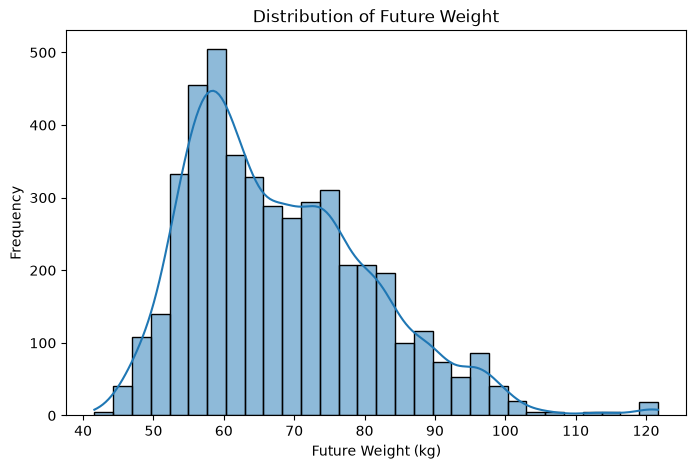

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_model["future_weight"],
    bins=30,
    kde=True
)

plt.title("Distribution of Future Weight")
plt.xlabel("Future Weight (kg)")
plt.ylabel("Frequency")

plt.show()

In [39]:
df_model["weight_change"] = (
    df_model["future_weight"] - df_model["weight"]
)

display(
    df_model["weight_change"].describe()
)

count    4578.000000
mean       -0.122095
std         0.413249
min        -2.300000
25%        -0.300000
50%        -0.100000
75%         0.000000
max         2.600000
Name: weight_change, dtype: float64

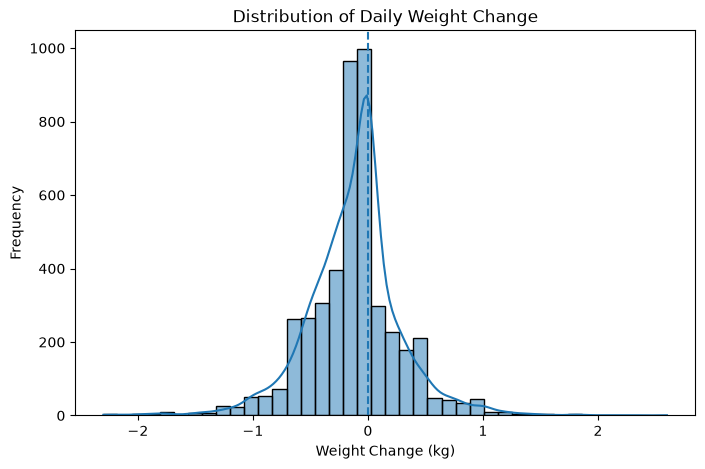

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_model["weight_change"],
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Daily Weight Change")
plt.xlabel("Weight Change (kg)")
plt.ylabel("Frequency")

plt.show()

## 5. Feature Engineering

Features are constructed from information that would be available
at prediction time.

The main numerical features represent recent weight history,
while dietary information is represented as combined meal
ingredient text.

The target `future_weight` is not used to construct any input
feature.

In [41]:
df_model["previous_weight"] = (
    df_model.groupby("ID")["weight"].shift(1)
)

df_model["historical_weight_change"] = (
    df_model["weight"] - df_model["previous_weight"]
)

display(
    df_model[
        [
            "ID",
            "date",
            "previous_weight",
            "weight",
            "historical_weight_change",
            "future_weight"
        ]
    ].head(15)
)

,ID,date,previous_weight,weight,historical_weight_change,future_weight
0,0060b6899180e194092d60a0e50aeea1,2019-02-22,NaN,68.3,NaN,68.8
1,0060b6899180e194092d60a0e50aeea1,2019-02-23,68.3,68.8,0.5,68.2
2,0060b6899180e194092d60a0e50aeea1,2019-02-24,68.8,68.2,-0.6,68.2
3,0060b6899180e194092d60a0e50aeea1,2019-02-25,68.2,68.2,0.0,68.2
4,0060b6899180e194092d60a0e50aeea1,2019-02-26,68.2,68.2,0.0,68.2
5,0176f16327965da04ee40c41cc4df2e5,2019-01-10,NaN,74.8,NaN,75.0
6,0176f16327965da04ee40c41cc4df2e5,2019-01-11,74.8,75.0,0.2,74.3
7,0176f16327965da04ee40c41cc4df2e5,2019-01-12,75.0,74.3,-0.7,73.8
8,0176f16327965da04ee40c41cc4df2e5,2019-01-13,74.3,73.8,-0.5,74.0
9,0176f16327965da04ee40c41cc4df2e5,2019-01-14,73.8,74.0,0.2,74.8


In [42]:
print(
    "Rows without previous weight:",
    df_model["previous_weight"].isna().sum()
)

Rows without previous weight: 611


In [43]:
df_model = df_model.dropna(
    subset=["previous_weight"]
).copy()

df_model = df_model.reset_index(drop=True)

print("Records after historical feature preparation:", len(df_model))

Records after historical feature preparation: 3967


In [44]:
df_model["dietary_text"] = (
    "breakfast " + df_model["breakfast_ingredients"] +
    " lunch " + df_model["lunch_ingredients"] +
    " supper " + df_model["supper_ingredients"]
)

In [45]:
display(
    df_model[
        [
            "ID",
            "date",
            "dietary_text",
            "previous_weight",
            "weight",
            "historical_weight_change",
            "future_weight"
        ]
    ].head(10)
)

,ID,date,dietary_text,previous_weight,weight,historical_weight_change,future_weight
0,0060b6899180e194092d60a0e50aeea1,2019-02-23,breakfast egg tomato rice lunch cabbage soup r...,68.3,68.8,0.5,68.2
1,0060b6899180e194092d60a0e50aeea1,2019-02-24,breakfast porridge water apple lunch chicken c...,68.8,68.2,-0.6,68.2
2,0060b6899180e194092d60a0e50aeea1,2019-02-25,breakfast milk egg lunch noodle supper potato ...,68.2,68.2,0.0,68.2
3,0060b6899180e194092d60a0e50aeea1,2019-02-26,breakfast orange milk lunch vegetable supper c...,68.2,68.2,0.0,68.2
4,0176f16327965da04ee40c41cc4df2e5,2019-01-11,breakfast water lunch rice supper cabbage rice,74.8,75.0,0.2,74.3
5,0176f16327965da04ee40c41cc4df2e5,2019-01-12,breakfast water lunch egg spareribs rice suppe...,75.0,74.3,-0.7,73.8
6,0176f16327965da04ee40c41cc4df2e5,2019-01-13,breakfast water lunch shrimp soup spinach rice...,74.3,73.8,-0.5,74.0
7,0176f16327965da04ee40c41cc4df2e5,2019-01-14,breakfast water lunch sausage sprout green ric...,73.8,74.0,0.2,74.8
8,01a145f7330442d8d8e2925c83cc846f,2018-07-20,breakfast egg lettuce lunch tofu potato supper...,62.9,62.0,-0.9,61.0
9,01a145f7330442d8d8e2925c83cc846f,2018-07-21,breakfast milk egg lunch vegetable bean cucumb...,62.0,61.0,-1.0,60.8


### Group-Based Train-Test Split

Multiple records belong to the same participant. Therefore,
the dataset is split by participant ID rather than individual
rows.

This prevents records from the same participant from appearing
in both training and test sets and provides a more realistic
evaluation of generalization to unseen participants.

In [46]:
from sklearn.model_selection import GroupShuffleSplit

X = df_model[
    [
        "previous_weight",
        "weight",
        "historical_weight_change",
        "dietary_text"
    ]
].copy()

y = df_model["future_weight"].copy()

groups = df_model["ID"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training records:", len(X_train))
print("Test records:", len(X_test))

print(
    "Training participants:",
    X_train.index.to_series().map(df_model["ID"]).nunique()
)

print(
    "Test participants:",
    X_test.index.to_series().map(df_model["ID"]).nunique()
)

Training records: 3214
Test records: 753
Training participants: 488
Test participants: 123


In [47]:
train_users = set(
    df_model.loc[X_train.index, "ID"]
)

test_users = set(
    df_model.loc[X_test.index, "ID"]
)

overlap = train_users.intersection(test_users)

print("Overlapping participants:", len(overlap))

Overlapping participants: 0


## 6. Text Feature Engineering

Dietary ingredient information is represented as text.

TF-IDF (Term Frequency-Inverse Document Frequency) is used to
transform the dietary text into numerical features based on the
importance of words across the dataset.

The TF-IDF vectorizer is fitted only on the training data to
prevent information leakage from the test set.

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [49]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=300
)

In [50]:
X_train_text = tfidf.fit_transform(
    X_train["dietary_text"]
)

X_test_text = tfidf.transform(
    X_test["dietary_text"]
)

print("Training TF-IDF shape:", X_train_text.shape)
print("Test TF-IDF shape:", X_test_text.shape)

Training TF-IDF shape: (3214, 300)
Test TF-IDF shape: (753, 300)


In [51]:
from scipy.sparse import hstack

numeric_train = X_train[
    [
        "previous_weight",
        "weight",
        "historical_weight_change"
    ]
].values

numeric_test = X_test[
    [
        "previous_weight",
        "weight",
        "historical_weight_change"
    ]
].values

In [52]:
X_train_final = hstack([
    numeric_train,
    X_train_text
])

X_test_final = hstack([
    numeric_test,
    X_test_text
])

print("Final training feature shape:", X_train_final.shape)
print("Final test feature shape:", X_test_final.shape)

Final training feature shape: (3214, 303)
Final test feature shape: (753, 303)


In [53]:
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 TF-IDF features:")
print(tfidf.get_feature_names_out()[:20])

Number of TF-IDF features: 300

First 20 TF-IDF features:
['apple' 'apple milk' 'artemisia' 'bamboo_shoot' 'bamboo_shoot supper'
 'banana' 'bean' 'bean porridge' 'bean rice' 'beef' 'beef lettuce'
 'beef meal_replacement_powder' 'beef porridge' 'beef potato'
 'beef tomato' 'beef vegetable' 'berry' 'bread' 'bread cucumber'
 'bread milk']


## 7. Model Training

Several regression models are evaluated using the same training
and test datasets.

The models are compared using Mean Absolute Error (MAE), Root
Mean Squared Error (RMSE), and R².

MAE represents the average absolute prediction error in kilograms.
RMSE gives greater weight to larger errors, while R² measures how
much variation in future weight is explained by the model.

In [54]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

In [55]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_final,
    y_train
)

linear_pred = linear_model.predict(
    X_test_final
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 0.3149183091673006
RMSE: 0.4291473155358502
R²  : 0.9984854473365098


In [56]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_final,
    y_train
)

ridge_pred = ridge_model.predict(
    X_test_final
)

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    )
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("Ridge Regression")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression
MAE : 0.2955428295941845
RMSE: 0.4123329270059682
R²  : 0.9986018054256476


In [57]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_final,
    y_train
)

rf_pred = rf_model.predict(
    X_test_final
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 0.3263128963686883
RMSE: 0.44903787142413276
R²  : 0.9983417976751353


In [58]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        ridge_r2,
        rf_r2
    ]
})

display(
    results.sort_values("MAE")
)

,Model,MAE,RMSE,R2
1,Ridge Regression,0.295543,0.412333,0.998602
0,Linear Regression,0.314918,0.429147,0.998485
2,Random Forest,0.326313,0.449038,0.998342


## 8. Model Evaluation

The three regression models are evaluated on the unseen test
participants.

Ridge Regression produces the lowest MAE and RMSE among the
evaluated models, while also achieving a high R² score.

The results indicate that recent weight history provides strong
information for predicting the next observed weight. The dietary
text features provide additional information through TF-IDF
representation.

Because the test set contains participants that were not present
in the training set, the evaluation measures the model's ability
to generalize to unseen participants.

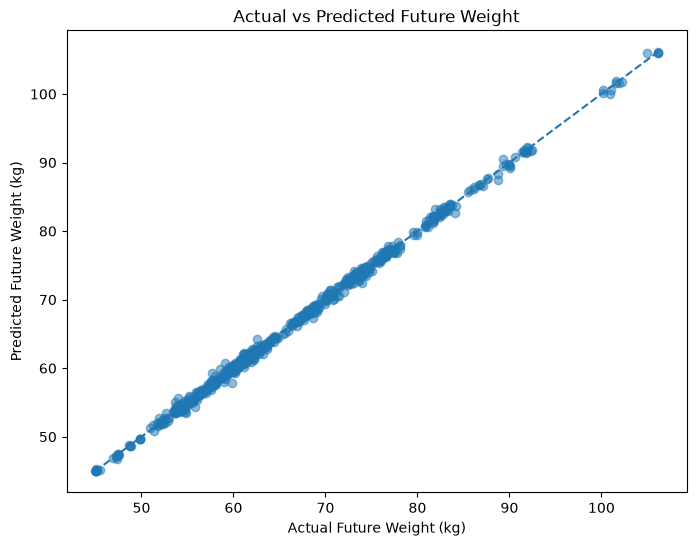

In [59]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    ridge_pred,
    alpha=0.5
)

min_value = min(y_test.min(), ridge_pred.min())
max_value = max(y_test.max(), ridge_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Future Weight (kg)")
plt.ylabel("Predicted Future Weight (kg)")
plt.title("Actual vs Predicted Future Weight")

plt.show()

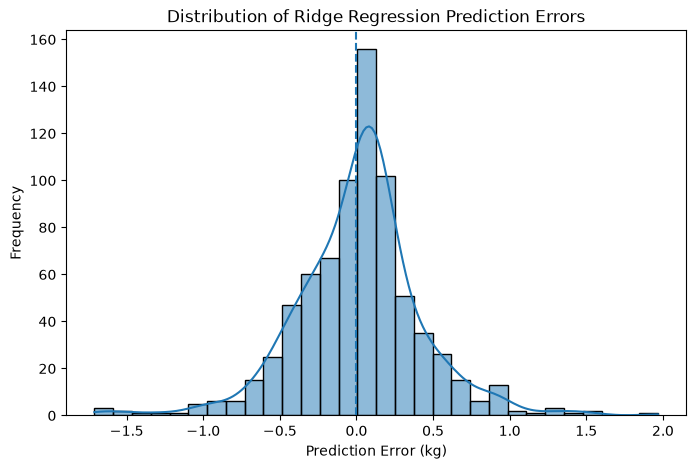

In [60]:
ridge_errors = y_test - ridge_pred

plt.figure(figsize=(8, 5))

sns.histplot(
    ridge_errors,
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (kg)")
plt.ylabel("Frequency")
plt.title("Distribution of Ridge Regression Prediction Errors")

plt.show()

In [61]:
print("Mean Error:", ridge_errors.mean())
print("Mean Absolute Error:", np.abs(ridge_errors).mean())
print("Minimum Error:", ridge_errors.min())
print("Maximum Error:", ridge_errors.max())

Mean Error: 0.015360708932102115
Mean Absolute Error: 0.2955428295941845
Minimum Error: -1.7106072095233102
Maximum Error: 1.9678606134850654


In [62]:
evaluation = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Value": [
        ridge_mae,
        ridge_rmse,
        ridge_r2
    ]
})

display(evaluation)

,Metric,Value
0,MAE,0.295543
1,RMSE,0.412333
2,R²,0.998602


## 9. Final Model Training

Ridge Regression is selected as the final model because it achieved
the lowest MAE and RMSE among the evaluated models.

The final model is retrained using all training-ready records so
that the available dataset can be utilized before deployment.

The TF-IDF vectorizer is also refitted on the complete training-ready
dataset and saved together with the regression model.

In [63]:
import joblib
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

In [64]:
X_final = df_model[
    [
        "previous_weight",
        "weight",
        "historical_weight_change",
        "dietary_text"
    ]
].copy()

y_final = df_model["future_weight"].copy()

print("Final training records:", len(X_final))

Final training records: 3967


In [65]:
final_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=300
)

final_text_features = final_tfidf.fit_transform(
    X_final["dietary_text"]
)

print("Final TF-IDF shape:", final_text_features.shape)

Final TF-IDF shape: (3967, 300)


In [66]:
final_numeric_features = X_final[
    [
        "previous_weight",
        "weight",
        "historical_weight_change"
    ]
].values

X_final_features = hstack([
    final_numeric_features,
    final_text_features
])

print("Final feature shape:", X_final_features.shape)

Final feature shape: (3967, 303)


In [67]:
final_model = Ridge(alpha=1.0)

final_model.fit(
    X_final_features,
    y_final
)

print("Final Ridge model trained successfully.")

Final Ridge model trained successfully.


In [68]:
model_bundle = {
    "model": final_model,
    "tfidf": final_tfidf,
    "numeric_features": [
        "previous_weight",
        "weight",
        "historical_weight_change"
    ]
}

In [ ]:
model_path = Path("../model/dietly_weight_model.joblib")

joblib.dump(
    model_bundle,
    model_path
)

print("Model saved to:", model_path.resolve())
print("Model size:", model_path.stat().st_size, "bytes")

In [70]:
loaded_bundle = joblib.load(model_path)

loaded_model = loaded_bundle["model"]
loaded_tfidf = loaded_bundle["tfidf"]

print("Model loaded successfully.")
print("TF-IDF vocabulary size:", len(loaded_tfidf.vocabulary_))

Model loaded successfully.
TF-IDF vocabulary size: 300


In [71]:
sample = X_final.iloc[0]

sample_numeric = sample[
    [
        "previous_weight",
        "weight",
        "historical_weight_change"
    ]
].astype(float).values.reshape(1, -1)

sample_text = loaded_tfidf.transform(
    [str(sample["dietary_text"])]
)

sample_features = hstack([
    sample_numeric,
    sample_text
])

sample_prediction = loaded_model.predict(
    sample_features
)[0]

print("Actual future weight:", y_final.iloc[0])
print("Predicted future weight:", sample_prediction)

Actual future weight: 68.2
Predicted future weight: 68.56056160513958
